<a href="https://colab.research.google.com/github/ashuuu2505-prog/Internship/blob/main/Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!ls

sample_data  train.csv.zip


In [2]:
!unzip train.csv.zip

Archive:  train.csv.zip
   creating: train.csv/
  inflating: train.csv/holidays_events.csv  
  inflating: train.csv/oil.csv       
  inflating: train.csv/sample_submission.csv  
  inflating: train.csv/stores.csv    
  inflating: train.csv/test.csv      
  inflating: train.csv/train.csv     
  inflating: train.csv/transactions.csv  


In [5]:
import os
os.listdir()

['.config', 'train.csv.zip', 'train.csv', 'sample_data']

In [6]:
os.listdir('train.csv')

['test.csv',
 'sample_submission.csv',
 'stores.csv',
 'transactions.csv',
 'holidays_events.csv',
 'train.csv',
 'oil.csv']

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [15]:
import pandas as pd

train = pd.read_csv("train.csv/train.csv")
test = pd.read_csv("train.csv/test.csv")
stores = pd.read_csv("train.csv/stores.csv")
transactions = pd.read_csv("train.csv/transactions.csv")
oil = pd.read_csv("train.csv/oil.csv")
holidays = pd.read_csv("train.csv/holidays_events.csv")

In [17]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [18]:
stores.head()
transactions.head()
oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [19]:
train['date'] = pd.to_datetime(train['date'])
oil['date'] = pd.to_datetime(oil['date'])

In [21]:
transactions['date'] = pd.to_datetime(transactions['date'])

In [22]:
# Convert date columns
train['date'] = pd.to_datetime(train['date'])
oil['date'] = pd.to_datetime(oil['date'])
transactions['date'] = pd.to_datetime(transactions['date'])  # 🔥 FIX

# Merge datasets
data = train.merge(stores, on='store_nbr', how='left')
data = data.merge(oil, on='date', how='left')
data = data.merge(transactions, on=['date','store_nbr'], how='left')

# Fill missing values
data.fillna(0, inplace=True)

# Check result
data.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,0.0,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,0.0,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,0.0,0.0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,0.0,0.0


In [23]:
# Extract date features
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
data['dayofweek'] = data['date'].dt.dayofweek

# Create lag features
data['lag_1'] = data['sales'].shift(1)
data['lag_7'] = data['sales'].shift(7)

# Fill missing values again
data.fillna(0, inplace=True)

data.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions,year,month,day,dayofweek,lag_1,lag_7
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,0.0,2013,1,1,1,0.0,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,0.0,0.0,2013,1,1,1,0.0,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,0.0,0.0,2013,1,1,1,0.0,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,0.0,0.0,2013,1,1,1,0.0,0.0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,0.0,0.0,2013,1,1,1,0.0,0.0


In [24]:
# Convert categorical column
data['family'] = data['family'].astype(str)

# Select features
X = data[['store_nbr','onpromotion','dcoilwtico','transactions',
          'year','month','day','dayofweek','lag_1','lag_7']]

# Encode 'family'
family_encoded = pd.get_dummies(data['family'], prefix='family')
X = pd.concat([X, family_encoded], axis=1)

# Target variable
y = data['sales']

In [25]:
train_data = data[data['date'] < '2017-01-01']
test_data = data[data['date'] >= '2017-01-01']

X_train = X.loc[train_data.index]
X_test = X.loc[test_data.index]

y_train = y.loc[train_data.index]
y_test = y.loc[test_data.index]

In [28]:
# Take small sample (VERY IMPORTANT)
data_sample = data.sample(20000, random_state=42)

X_sample = X.loc[data_sample.index]
y_sample = y.loc[data_sample.index]

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=5, random_state=42)
model.fit(X_sample, y_sample)

RandomForestRegressor(n_estimators=5, random_state=42)

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 119.32704448358355
RMSE: 433.476786605166
R2 Score: 0.8976868281816792


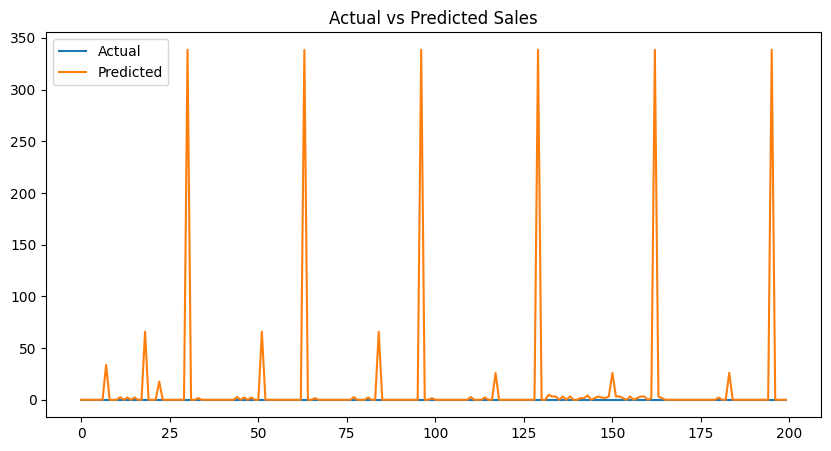

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

**Conclusion:**

1. Sales trends and seasonal patterns were analyzed.
2. Feature engineering improved model performance.
3. Random Forest model gave good prediction accuracy.
4. This model can help in demand forecasting and inventory planning.